# FractalScope v1.1

This notebook demonstrates the implemented PS → PL → DDR → HDMI workflow:

```text
Python/PYNQ control
    → AXI-Lite scheduler registers
    → PL fractal render pipeline
    → AXI VDMA S2MM capture buffer
    → PS-side packing and optional HUD overlay
    → AXI VDMA MM2S display buffer
    → HDMI output
```

Implemented fractal modes in this build:

- Mandelbrot
- Julia
- Burning Ship
- Tricorn

Run the notebook from top to bottom after restarting the kernel.

## 1. Load the overlay

Add the .bit and .hwh files to a fractalscope/ folder in the homepage

In [ ]:
from pathlib import Path
from pynq import Overlay, MMIO, allocate
import numpy as np
import time
import pprint

# Change this if your notebook folder is somewhere else on the PYNQ board.
PROJECT_DIR = Path("/home/xilinx/jupyter_notebooks/fractalscope")
BIT_PATH = PROJECT_DIR / "fractalscope.bit"
HWH_PATH = PROJECT_DIR / "fractalscope.hwh"

SHOW_IPS = False

print("Using bitstream:", BIT_PATH)
print("Using HWH:      ", HWH_PATH)

assert BIT_PATH.exists(), f"Missing bitstream: {BIT_PATH}"
assert HWH_PATH.exists(), f"Missing hardware handoff: {HWH_PATH}"

ol = Overlay(str(BIT_PATH), download=True)
print("Overlay loaded.")

if SHOW_IPS:
    pprint.pprint(list(ol.ip_dict.keys()))

"""Return an MMIO object for a named AXI-Lite IP in the loaded HWH."""
def require_ip(name):
    assert name in ol.ip_dict, f"IP not found in HWH: {name}. Available IPs: {list(ol.ip_dict.keys())}"
    info = ol.ip_dict[name]
    assert "phys_addr" in info, f"IP {name} has no phys_addr entry"
    return MMIO(info["phys_addr"], info["addr_range"])


vdma = require_ip("axi_vdma_0")

# for if the sched cant be found automatically by name
SCHEDULER_BASE_ADDR = None


def find_scheduler_mmio():
    candidates = []
    for name, info in ol.ip_dict.items():
        lower_name = name.lower()
        lower_type = str(info.get("type", "")).lower()
        if "phys_addr" not in info:
            continue
        if "pixel" in lower_name or "scheduler" in lower_name or "pixel_scheduler" in lower_type:
            candidates.append((name, info["phys_addr"], info["addr_range"], info.get("type")))

    if candidates:
        name, addr, addr_range, ip_type = candidates[0]
        print(f"Scheduler IP: {name} at {hex(addr)} ({ip_type})")
        return MMIO(addr, addr_range)

    if SCHEDULER_BASE_ADDR is not None:
        print(f"Scheduler IP not found by name; using manual base address {hex(SCHEDULER_BASE_ADDR)}")
        return MMIO(SCHEDULER_BASE_ADDR, 0x1000)

    raise RuntimeError("Could not find the pixel scheduler AXI-Lite IP. Set SCHEDULER_BASE_ADDR manually.")


sched = find_scheduler_mmio()
print("VDMA base:", hex(ol.ip_dict["axi_vdma_0"]["phys_addr"]))

Using bitstream: /home/xilinx/jupyter_notebooks/fractalscope/fractalscope.bit
Using HWH:       /home/xilinx/jupyter_notebooks/fractalscope/fractalscope.hwh
Note: PYNQ file timestamps can be unreliable; trust your copied files if you know they are current.
Overlay loaded.
Scheduler IP: pixel_scheduler_top_0 at 0x40000000 (xilinx.com:user:pixel_scheduler_top:1.0)
VDMA base: 0x43000000


## 2. Geometry, buffers, and scheduler register map

The PL pipeline writes 24-bit RGB into `recv_fb` through S2MM. The notebook then packs that into a 32-bit display framebuffer, `display_fb`, for MM2S and HDMI.

In [ ]:
# Display geometry
WIDTH = 1280
HEIGHT = 720

# Pixel formats
CAPTURE_BPP = 3   # S2MM writes RGB888 into shape=(HEIGHT, WIDTH, 3), dtype=uint8
DISPLAY_BPP = 4   # MM2S reads packed 0x00RRGGBB words from shape=(HEIGHT, WIDTH), dtype=uint32

recv_fb = allocate(shape=(HEIGHT, WIDTH, CAPTURE_BPP), dtype=np.uint8)
display_fb = allocate(shape=(HEIGHT, WIDTH), dtype=np.uint32)

recv_fb[:] = 0
display_fb[:] = 0
recv_fb.flush()
display_fb.flush()

print("recv_fb physical address:   ", hex(recv_fb.physical_address))
print("display_fb physical address:", hex(display_fb.physical_address))

# Pixel scheduler AXI-Lite register offsets.
REG_X_JUMP   = 0x00
REG_Y_JUMP   = 0x04
REG_X_MIN    = 0x08
REG_Y_MIN    = 0x0C
REG_JULIA_CR = 0x10
REG_JULIA_CI = 0x14
REG_ITERMODE = 0x18   # {mode[18:16], max_iter[15:0]}
REG_RUN      = 0x1C   # software_run / render reset release

MODE_MANDELBROT  = 0
MODE_JULIA       = 1
MODE_BURNINGSHIP = 2
MODE_TRICORN     = 3

FRACTAL_MODES = {
    "mandelbrot": MODE_MANDELBROT,
    "mandel": MODE_MANDELBROT,
    "m": MODE_MANDELBROT,
    "julia": MODE_JULIA,
    "j": MODE_JULIA,
    "burning_ship": MODE_BURNINGSHIP,
    "burningship": MODE_BURNINGSHIP,
    "burning": MODE_BURNINGSHIP,
    "ship": MODE_BURNINGSHIP,
    "b": MODE_BURNINGSHIP,
    "tricorn": MODE_TRICORN,
    "tri": MODE_TRICORN,
    "t": MODE_TRICORN,
}

MODE_NAMES = {
    MODE_MANDELBROT: "mandelbrot",
    MODE_JULIA: "julia",
    MODE_BURNINGSHIP: "burning_ship",
    MODE_TRICORN: "tricorn",
}

# Q4.22 signed fixed-point format used by the RTL coordinate inputs.
Q_FRAC = 22
Q_WIDTH = 26
Q_SCALE = 1 << Q_FRAC
Q_MASK = (1 << Q_WIDTH) - 1
Q_SIGN = 1 << (Q_WIDTH - 1)


def to_q422(value):
    raw = int(round(float(value) * Q_SCALE))
    return raw & Q_MASK


def from_q422(raw):
    raw = int(raw) & Q_MASK
    if raw & Q_SIGN:
        raw -= (1 << Q_WIDTH)
    return raw / Q_SCALE


def pack_iter_mode(max_iter, mode):
    max_iter = int(max_iter)
    mode = int(mode)
    assert 1 <= max_iter <= 65535, "max_iter must fit in 16 bits and be non-zero"
    assert 0 <= mode < 8, "mode must fit in 3 bits"
    return (mode << 16) | (max_iter & 0xFFFF)


def normalise_mode(fractal):
    if isinstance(fractal, str):
        key = fractal.strip().lower().replace("-", "_").replace(" ", "_")
        assert key in FRACTAL_MODES, f"Unknown fractal '{fractal}'. Available: {sorted(set(FRACTAL_MODES))}"
        return FRACTAL_MODES[key]
    mode = int(fractal)
    assert mode in MODE_NAMES, f"Unknown fractal mode {mode}"
    return mode

recv_fb physical address:    0x15900000
display_fb physical address: 0x15c00000


## 3. VDMA helpers

These helpers set up the two VDMA directions:

- `S2MM`: PL stream to DDR capture buffer
- `MM2S`: DDR display buffer to HDMI stream

The control register start helper preserves existing VDMA control bits while setting run/circular mode.

In [ ]:
# VDMA register offsets
MM2S_DMACR       = 0x00
MM2S_DMASR       = 0x04
MM2S_VSIZE       = 0x50
MM2S_HSIZE       = 0x54
MM2S_FRMDLY_STRD = 0x58
MM2S_START_ADDR1 = 0x5C
MM2S_START_ADDR2 = 0x60
MM2S_START_ADDR3 = 0x64

S2MM_DMACR       = 0x30
S2MM_DMASR       = 0x34
S2MM_VSIZE       = 0xA0
S2MM_HSIZE       = 0xA4
S2MM_FRMDLY_STRD = 0xA8
S2MM_START_ADDR1 = 0xAC
S2MM_START_ADDR2 = 0xB0
S2MM_START_ADDR3 = 0xB4

VDMA_CR_RS = 1 << 0
VDMA_CR_CIRC = 1 << 1
VDMA_CR_RESET = 1 << 2
VDMA_IRQ_ERROR_MASK = (1 << 4) | (1 << 5) | (1 << 6) | (1 << 8) | (1 << 9) | (1 << 10) | (1 << 13)

DISPLAY_RUNNING = False


def decode_vdma_status(sr):
    flags = []
    if sr & (1 << 0): flags.append("HALTED")
    if sr & (1 << 1): flags.append("IDLE")
    if sr & (1 << 4): flags.append("VDMA_INTERNAL_ERROR")
    if sr & (1 << 5): flags.append("VDMA_SLAVE_ERROR")
    if sr & (1 << 6): flags.append("VDMA_DECODE_ERROR")
    if sr & (1 << 8): flags.append("START_OF_FRAME_EARLY")
    if sr & (1 << 9): flags.append("END_OF_LINE_EARLY")
    if sr & (1 << 10): flags.append("START_OF_FRAME_LATE")
    if sr & (1 << 11): flags.append("FRAME_COUNT_IRQ")
    if sr & (1 << 12): flags.append("DELAY_COUNT_IRQ")
    if sr & (1 << 13): flags.append("ERROR_IRQ")
    if sr & (1 << 16): flags.append("PARKED_OR_FRAME_SYNC")
    return flags


def get_vdma_status():
    return {
        "mm2s_dmacr": vdma.read(MM2S_DMACR),
        "mm2s_dmasr": vdma.read(MM2S_DMASR),
        "s2mm_dmacr": vdma.read(S2MM_DMACR),
        "s2mm_dmasr": vdma.read(S2MM_DMASR),
    }


def clear_vdma_status():
    # VDMA status bits are write-one-to-clear.
    vdma.write(MM2S_DMASR, 0x0000FFFF)
    vdma.write(S2MM_DMASR, 0x0000FFFF)


def wait_reset_clear(control_offset, name, timeout_s=3.0, strict=True):
    deadline = time.time() + timeout_s
    while time.time() < deadline:
        if (vdma.read(control_offset) & VDMA_CR_RESET) == 0:
            return True
        time.sleep(0.01)

    message = f"{name} reset bit did not clear within {timeout_s:.1f}s"
    if strict:
        raise RuntimeError(message)
    print("Warning:", message)
    return False


def reset_mm2s(strict=True):
    global DISPLAY_RUNNING
    DISPLAY_RUNNING = False
    vdma.write(MM2S_DMACR, vdma.read(MM2S_DMACR) | VDMA_CR_RESET)
    ok = wait_reset_clear(MM2S_DMACR, "MM2S", strict=strict)
    clear_vdma_status()
    return ok


def reset_s2mm(strict=True):
    vdma.write(S2MM_DMACR, vdma.read(S2MM_DMACR) | VDMA_CR_RESET)
    ok = wait_reset_clear(S2MM_DMACR, "S2MM", strict=strict)
    clear_vdma_status()
    return ok


def start_control_preserve(control_offset):
    cr = vdma.read(control_offset)
    cr &= ~VDMA_CR_RESET
    cr |= VDMA_CR_RS | VDMA_CR_CIRC
    vdma.write(control_offset, cr)
    return vdma.read(control_offset)


def start_s2mm_capture(buffer):
    """Arm S2MM to capture one rendered RGB frame into DDR."""
    reset_s2mm(strict=True)

    addr = int(buffer.physical_address)
    vdma.write(S2MM_START_ADDR1, addr)
    vdma.write(S2MM_START_ADDR2, addr)
    vdma.write(S2MM_START_ADDR3, addr)
    vdma.write(S2MM_FRMDLY_STRD, WIDTH * CAPTURE_BPP)
    vdma.write(S2MM_HSIZE, WIDTH * CAPTURE_BPP)
    start_control_preserve(S2MM_DMACR)

    # VSIZE is written last to start the channel.
    vdma.write(S2MM_VSIZE, HEIGHT)


def start_mm2s_display(buffer, force_restart=False):
    """Start HDMI output from the display framebuffer."""
    global DISPLAY_RUNNING

    if DISPLAY_RUNNING and not force_restart:
        buffer.flush()
        return

    reset_mm2s(strict=True)

    addr = int(buffer.physical_address)
    vdma.write(MM2S_START_ADDR1, addr)
    vdma.write(MM2S_START_ADDR2, addr)
    vdma.write(MM2S_START_ADDR3, addr)
    vdma.write(MM2S_FRMDLY_STRD, WIDTH * DISPLAY_BPP)
    vdma.write(MM2S_HSIZE, WIDTH * DISPLAY_BPP)
    start_control_preserve(MM2S_DMACR)

    # VSIZE is written last to start the channel.
    vdma.write(MM2S_VSIZE, HEIGHT)
    time.sleep(0.20)
    DISPLAY_RUNNING = True


def stop_display():
    global DISPLAY_RUNNING
    DISPLAY_RUNNING = False
    vdma.write(MM2S_DMACR, 0)
    time.sleep(0.05)

: 

## 4. Viewport, scheduler programming, and frame helpers

These functions convert human-readable fractal parameters into the fixed-point scheduler registers expected by the RTL.

In [ ]:
def make_view(center_x=-0.5, center_y=0.0, x_width=3.5):
    x_width = float(x_width)
    y_height = x_width * HEIGHT / WIDTH
    return {
        "center_x": float(center_x),
        "center_y": float(center_y),
        "x_width": x_width,
        "y_height": y_height,
        "x_min": float(center_x) - x_width / 2.0,
        "x_max": float(center_x) + x_width / 2.0,
        "y_min": float(center_y) - y_height / 2.0,
        "y_max": float(center_y) + y_height / 2.0,
        "x_jump": x_width / WIDTH,
        "y_jump": y_height / HEIGHT,
    }


def print_view(view):
    print("center = ({:.12f}, {:.12f})".format(view["center_x"], view["center_y"]))
    print("x range = [{:.12f}, {:.12f}] width {:.12g}".format(view["x_min"], view["x_max"], view["x_width"]))
    print("y range = [{:.12f}, {:.12f}] height {:.12g}".format(view["y_min"], view["y_max"], view["y_height"]))
    print("x_jump = {:.12g}, y_jump = {:.12g}".format(view["x_jump"], view["y_jump"]))


def program_scheduler(fractal="mandelbrot", view=None, max_iter=256, julia_c=(-0.8, 0.156)):
    if view is None:
        view = make_view()

    mode = normalise_mode(fractal)

    # Hold the render pipeline while programming a new frame.
    sched.write(REG_RUN, 0)
    time.sleep(0.02)

    sched.write(REG_X_JUMP, to_q422(view["x_jump"]))
    sched.write(REG_Y_JUMP, to_q422(view["y_jump"]))
    sched.write(REG_X_MIN, to_q422(view["x_min"]))
    sched.write(REG_Y_MIN, to_q422(view["y_min"]))
    sched.write(REG_JULIA_CR, to_q422(julia_c[0]))
    sched.write(REG_JULIA_CI, to_q422(julia_c[1]))
    sched.write(REG_ITERMODE, pack_iter_mode(max_iter, mode))

    # render_hardware() releases the pipeline after S2MM is armed.
    sched.write(REG_RUN, 0)
    time.sleep(0.01)


def frame_stats(frame):
    return {
        "min": int(frame.min()),
        "max": int(frame.max()),
        "mean": float(frame.mean()),
        "nonzero": int(np.count_nonzero(frame)),
    }


def pack_rgb24_to_display32(src_rgb, dst_u32):
    r = src_rgb[:, :, 0].astype(np.uint32)
    g = src_rgb[:, :, 1].astype(np.uint32)
    b = src_rgb[:, :, 2].astype(np.uint32)
    dst_u32[:, :] = (r << 16) | (g << 8) | b


def fill_rect_u32(dst_u32, x0, y0, w, h, colour):
    x0 = max(0, min(WIDTH, int(x0)))
    y0 = max(0, min(HEIGHT, int(y0)))
    x1 = max(0, min(WIDTH, int(x0 + w)))
    y1 = max(0, min(HEIGHT, int(y0 + h)))
    if x1 > x0 and y1 > y0:
        dst_u32[y0:y1, x0:x1] = np.uint32(colour)


def draw_crosshair_u32(dst_u32, x=None, y=None, colour=0x00FFFFFF, half=14):
    if x is None:
        x = WIDTH // 2
    if y is None:
        y = HEIGHT // 2
    x = int(x)
    y = int(y)
    x0 = max(0, x - half)
    x1 = min(WIDTH, x + half + 1)
    y0 = max(0, y - half)
    y1 = min(HEIGHT, y + half + 1)
    if 0 <= y < HEIGHT:
        dst_u32[y, x0:x1] = np.uint32(colour)
    if 0 <= x < WIDTH:
        dst_u32[y0:y1, x] = np.uint32(colour)


def try_draw_text_pil(dst_u32, lines, x=12, y=12):
    """Optional text overlay. Falls back silently if PIL is unavailable."""
    try:
        from PIL import Image, ImageDraw
    except Exception:
        return False

    rgb = np.empty((HEIGHT, WIDTH, 3), dtype=np.uint8)
    rgb[:, :, 0] = ((dst_u32 >> 16) & 0xFF).astype(np.uint8)
    rgb[:, :, 1] = ((dst_u32 >> 8) & 0xFF).astype(np.uint8)
    rgb[:, :, 2] = (dst_u32 & 0xFF).astype(np.uint8)

    img = Image.fromarray(rgb, mode="RGB")
    draw = ImageDraw.Draw(img)
    yy = y
    for line in lines:
        draw.text((x, yy), str(line), fill=(255, 255, 255))
        yy += 14

    arr = np.asarray(img)
    dst_u32[:, :] = (arr[:, :, 0].astype(np.uint32) << 16) | (arr[:, :, 1].astype(np.uint32) << 8) | arr[:, :, 2].astype(np.uint32)
    return True


def draw_overlay_u32(dst_u32, state=None, result=None, enable_text=True):
    """Draw a lightweight PS-side HUD over the HDMI framebuffer."""
    dst_u32[0:2, :] = np.uint32(0x00FFFFFF)
    dst_u32[-2:, :] = np.uint32(0x00FFFFFF)
    dst_u32[:, 0:2] = np.uint32(0x00FFFFFF)
    dst_u32[:, -2:] = np.uint32(0x00FFFFFF)

    draw_crosshair_u32(dst_u32, WIDTH // 2, HEIGHT // 2, colour=0x00FFFFFF)

    fill_rect_u32(dst_u32, 8, 8, 430, 90, 0x00000000)
    fill_rect_u32(dst_u32, 8, 8, 430, 2, 0x00FFFFFF)
    fill_rect_u32(dst_u32, 8, 96, 430, 2, 0x00FFFFFF)
    fill_rect_u32(dst_u32, 8, 8, 2, 90, 0x00FFFFFF)
    fill_rect_u32(dst_u32, 436, 8, 2, 90, 0x00FFFFFF)

    if enable_text:
        source = state if state is not None else result
        if source is None:
            lines = ["FractalScope v1.1"]
        else:
            lines = [
                "FractalScope v1.1",
                "mode={} iter={}".format(source.get("fractal"), source.get("max_iter")),
                "center=({:.6f},{:.6f})".format(source.get("center", (0, 0))[0], source.get("center", (0, 0))[1]),
                "width={:.6g}".format(source.get("x_width")),
            ]
        try_draw_text_pil(dst_u32, lines, x=16, y=16)


def estimate_wait(max_iter):
    # Conservative wait until a hardware frame-done bit is exposed in the control path.
    return max(1.2, min(5.0, 0.8 + 0.003 * int(max_iter)))

## 5. Render one hardware frame

`render_hardware()` is the main entry point. It programs the PL scheduler, captures the rendered frame, packs it for HDMI, optionally draws the HUD, and then updates the HDMI framebuffer.

In [ ]:
def render_hardware(
    fractal="mandelbrot",
    center=(-0.5, 0.0),
    x_width=3.5,
    max_iter=256,
    julia_c=(-0.8, 0.156),
    wait_s=None,
    preview=False,
    verbose=True,
    force_display_restart=False,
    allow_black_update=False,
    overlay=True,
    overlay_text=True,
):
    """Render one hardware frame and update HDMI if the captured frame is valid."""
    view = make_view(center_x=center[0], center_y=center[1], x_width=x_width)
    mode = normalise_mode(fractal)
    fractal_name = MODE_NAMES.get(mode, str(mode))

    if wait_s is None:
        wait_s = estimate_wait(max_iter)

    if verbose:
        print("\nRendering:", fractal_name)
        print("max_iter:", int(max_iter), "wait_s:", wait_s)
        if mode == MODE_JULIA:
            print("Julia c:", julia_c)
        print_view(view)

    # Keep the previous HDMI frame alive until the new capture is known to be usable.
    recv_fb[:] = 0
    recv_fb.flush()

    program_scheduler(fractal=mode, view=view, max_iter=max_iter, julia_c=julia_c)
    start_s2mm_capture(recv_fb)

    # Release the hardware render pipeline.
    sched.write(REG_RUN, 1)
    time.sleep(float(wait_s))

    recv_fb.invalidate()
    stats = frame_stats(recv_fb)

    vdma_state = get_vdma_status()
    mm2s_sr = vdma_state["mm2s_dmasr"]
    s2mm_sr = vdma_state["s2mm_dmasr"]
    errorish = bool((mm2s_sr | s2mm_sr) & VDMA_IRQ_ERROR_MASK)

    result = {
        "ok": False,
        "stats": stats,
        "fractal": fractal_name,
        "mode": mode,
        "center": tuple(center),
        "x_width": float(x_width),
        "max_iter": int(max_iter),
        "julia_c": tuple(julia_c),
        "view": view,
        "vdma": {
            "mm2s_flags": decode_vdma_status(mm2s_sr),
            "s2mm_flags": decode_vdma_status(s2mm_sr),
        },
    }

    if verbose:
        print("Captured frame stats:", stats)

    if stats["max"] == 0 and not allow_black_update:
        print("Warning: captured frame is all black, so HDMI was not overwritten.")
        print("Try increasing wait_s or rerunning with allow_black_update=True only if a black frame is expected.")
        result["reason"] = "all_black_capture"
        return result

    if errorish and verbose:
        print("Warning: VDMA reported flags:")
        print("  MM2S:", result["vdma"]["mm2s_flags"])
        print("  S2MM:", result["vdma"]["s2mm_flags"])

    pack_rgb24_to_display32(recv_fb, display_fb)

    if overlay:
        draw_overlay_u32(display_fb, result=result, enable_text=overlay_text)

    display_fb.flush()
    start_mm2s_display(display_fb, force_restart=force_display_restart)

    if preview:
        try:
            import matplotlib.pyplot as plt
            plt.figure(figsize=(12, 7))
            plt.imshow(recv_fb)
            plt.title("{} | center=({:.6f},{:.6f}) | width={:.6g} | iter={}".format(
                fractal_name, center[0], center[1], x_width, int(max_iter)
            ))
            plt.axis("off")
            plt.show()
        except Exception as e:
            print("Matplotlib preview failed:", repr(e))

    result["ok"] = True
    if verbose:
        print("HDMI updated.")
    return result

## 6. Presets

couple of presets generated by chatgpt which was can use for pres

In [ ]:
PRESETS = {
    # Mandelbrot
    "mandelbrot_full": {
        "fractal": "mandelbrot", "center": (-0.50, 0.00), "x_width": 3.50, "max_iter": 128,
    },
    "seahorse_valley": {
        "fractal": "mandelbrot", "center": (-0.740, 0.105), "x_width": 0.020, "max_iter": 256,
    },
    "elephant_valley": {
        "fractal": "mandelbrot", "center": (0.285, 0.010), "x_width": 0.080, "max_iter": 256,
    },
    "spiral_detail": {
        "fractal": "mandelbrot", "center": (-0.743643887, 0.131825904), "x_width": 0.010, "max_iter": 512,
    },
    "mini_mandelbrot": {
        "fractal": "mandelbrot", "center": (-1.75, 0.0), "x_width": 0.10, "max_iter": 256,
    },

    # Julia
    "julia_dragon": {
        "fractal": "julia", "center": (0.0, 0.0), "x_width": 3.20, "max_iter": 256, "julia_c": (-0.8, 0.156),
    },
    "julia_dendrite": {
        "fractal": "julia", "center": (0.0, 0.0), "x_width": 3.20, "max_iter": 256, "julia_c": (0.0, 1.0),
    },
    "julia_douady": {
        "fractal": "julia", "center": (0.0, 0.0), "x_width": 3.20, "max_iter": 256, "julia_c": (-0.123, 0.745),
    },
    "julia_airplane": {
        "fractal": "julia", "center": (0.0, 0.0), "x_width": 3.20, "max_iter": 256, "julia_c": (-1.754877666, 0.0),
    },
    "julia_spiral": {
        "fractal": "julia", "center": (0.0, 0.0), "x_width": 3.20, "max_iter": 256, "julia_c": (-0.70176, -0.3842),
    },

    # Burning Ship
    "burning_ship_full": {
        "fractal": "burning_ship", "center": (-0.5, -0.5), "x_width": 3.5, "max_iter": 128,
    },
    "burning_ship_detail": {
        "fractal": "burning_ship", "center": (-1.75, -0.03), "x_width": 0.12, "max_iter": 256,
    },
    "burning_ship_zoom": {
        "fractal": "burning_ship", "center": (-1.77, -0.01), "x_width": 0.04, "max_iter": 384,
    },

    # Tricorn
    "tricorn_full": {
        "fractal": "tricorn", "center": (0.0, 0.0), "x_width": 3.5, "max_iter": 128,
    },
    "tricorn_detail": {
        "fractal": "tricorn", "center": (-0.15, 0.65), "x_width": 0.55, "max_iter": 256,
    },
    "tricorn_zoom": {
        "fractal": "tricorn", "center": (-0.48, 0.57), "x_width": 0.20, "max_iter": 256,
    },
}


def show_presets():
    print("Available presets:")
    for name, p in PRESETS.items():
        jc = p.get("julia_c", None)
        extra = "" if jc is None else f", julia_c={jc}"
        print("  {:22s} fractal={:13s} center={} width={} iter={}{}".format(
            name, p["fractal"], p["center"], p["x_width"], p["max_iter"], extra
        ))


def render_preset(name, **kwargs):
    assert name in PRESETS, f"Unknown preset '{name}'. Run show_presets()."
    p = dict(PRESETS[name])
    return render_hardware(
        fractal=p["fractal"],
        center=p["center"],
        x_width=p["x_width"],
        max_iter=p["max_iter"],
        julia_c=p.get("julia_c", (-0.8, 0.156)),
        **kwargs,
    )


def cycle_presets(names=None, preview=False, force_first_restart=True, wait_between=0.5, **kwargs):
    if names is None:
        names = [
            "mandelbrot_full",
            "seahorse_valley",
            "julia_dragon",
            "julia_douady",
            "julia_dendrite",
            "julia_airplane",
            "julia_spiral",
            "burning_ship_full",
            "burning_ship_detail",
            "tricorn_full",
        ]

    # Safety filter
    names = [name for name in names if name != "tricorn_detail"]

    # Remove/disable overlay 
    kwargs["overlay"] = False

    results = {}
    first_render = True
    cycle_count = 1

    try:
        while True:
            for i, name in enumerate(names):
                results[name] = render_preset(
                    name,
                    preview=preview,
                    force_display_restart=(force_first_restart and first_render),
                    **kwargs,
                )

                first_render = False
                time.sleep(wait_between)

            cycle_count += 1

    except KeyboardInterrupt:
        print("\nStopped preset cycle.")
        return results


show_presets()

Available presets:
  mandelbrot_full        fractal=mandelbrot    center=(-0.5, 0.0) width=3.5 iter=128
  seahorse_valley        fractal=mandelbrot    center=(-0.74, 0.105) width=0.02 iter=256
  elephant_valley        fractal=mandelbrot    center=(0.285, 0.01) width=0.08 iter=256
  spiral_detail          fractal=mandelbrot    center=(-0.743643887, 0.131825904) width=0.01 iter=512
  mini_mandelbrot        fractal=mandelbrot    center=(-1.75, 0.0) width=0.1 iter=256
  julia_dragon           fractal=julia         center=(0.0, 0.0) width=3.2 iter=256, julia_c=(-0.8, 0.156)
  julia_dendrite         fractal=julia         center=(0.0, 0.0) width=3.2 iter=256, julia_c=(0.0, 1.0)
  julia_douady           fractal=julia         center=(0.0, 0.0) width=3.2 iter=256, julia_c=(-0.123, 0.745)
  julia_airplane         fractal=julia         center=(0.0, 0.0) width=3.2 iter=256, julia_c=(-1.754877666, 0.0)
  julia_spiral           fractal=julia         center=(0.0, 0.0) width=3.2 iter=256, julia_c=(-0.7

## 7. Stateful controls

These functions keep a current viewport in `STATE`, making zooming, panning, mode changes, and Julia constant changes easy

In [ ]:
STATE = {
    "fractal": "mandelbrot",
    "center": (-0.5, 0.0),
    "x_width": 3.5,
    "max_iter": 128,
    "julia_c": (-0.8, 0.156),
    "last": None,
}


def describe_state():
    print("Current state:")
    print("  fractal :", STATE["fractal"])
    print("  center  :", STATE["center"])
    print("  x_width :", STATE["x_width"])
    print("  max_iter:", STATE["max_iter"])
    print("  julia_c :", STATE["julia_c"])
    print_view(make_view(STATE["center"][0], STATE["center"][1], STATE["x_width"]))


def preset(name, render=True, **kwargs):
    assert name in PRESETS, f"Unknown preset '{name}'. Run show_presets()."
    p = PRESETS[name]
    STATE["fractal"] = p["fractal"]
    STATE["center"] = tuple(p["center"])
    STATE["x_width"] = float(p["x_width"])
    STATE["max_iter"] = int(p["max_iter"])
    STATE["julia_c"] = tuple(p.get("julia_c", STATE["julia_c"]))
    describe_state()
    if render:
        return render_current(**kwargs)


def set_fractal(fractal, render=False, **kwargs):
    mode = normalise_mode(fractal)
    STATE["fractal"] = MODE_NAMES[mode]
    describe_state()
    if render:
        return render_current(**kwargs)


def set_iters(max_iter, render=False, **kwargs):
    STATE["max_iter"] = int(max(1, min(65535, max_iter)))
    describe_state()
    if render:
        return render_current(**kwargs)


def set_center(x, y, render=False, **kwargs):
    STATE["center"] = (float(x), float(y))
    describe_state()
    if render:
        return render_current(**kwargs)


def set_width(x_width, render=False, **kwargs):
    STATE["x_width"] = float(max(1e-6, min(8.0, x_width)))
    describe_state()
    if render:
        return render_current(**kwargs)


def set_julia_c(real, imag, render=False, **kwargs):
    STATE["julia_c"] = (float(real), float(imag))
    describe_state()
    if render:
        return render_current(**kwargs)


def render_current(**kwargs):
    STATE["last"] = render_hardware(
        fractal=STATE["fractal"],
        center=STATE["center"],
        x_width=STATE["x_width"],
        max_iter=STATE["max_iter"],
        julia_c=STATE["julia_c"],
        **kwargs,
    )
    return STATE["last"]


def zoom_in(factor=2.0, **kwargs):
    STATE["x_width"] = max(1e-6, STATE["x_width"] / float(factor))
    return render_current(**kwargs)


def zoom_out(factor=2.0, **kwargs):
    STATE["x_width"] = min(8.0, STATE["x_width"] * float(factor))
    return render_current(**kwargs)


def pan(dx_frac=0.0, dy_frac=0.0, **kwargs):
    cx, cy = STATE["center"]
    xw = STATE["x_width"]
    yh = xw * HEIGHT / WIDTH
    STATE["center"] = (cx + float(dx_frac) * xw, cy + float(dy_frac) * yh)
    return render_current(**kwargs)


def pan_left(amount=0.25, **kwargs):
    return pan(dx_frac=-amount, dy_frac=0.0, **kwargs)


def pan_right(amount=0.25, **kwargs):
    return pan(dx_frac=amount, dy_frac=0.0, **kwargs)


def pan_up(amount=0.25, **kwargs):
    return pan(dx_frac=0.0, dy_frac=amount, **kwargs)


def pan_down(amount=0.25, **kwargs):
    return pan(dx_frac=0.0, dy_frac=-amount, **kwargs)


def nudge(dx_pixels=0, dy_pixels=0, **kwargs):
    """Pan by a number of screen pixels."""
    return pan(dx_frac=float(dx_pixels) / WIDTH, dy_frac=-float(dy_pixels) / HEIGHT, **kwargs)


def mode_next(render=True, **kwargs):
    mode = normalise_mode(STATE["fractal"])
    mode = (mode + 1) % len(MODE_NAMES)
    STATE["fractal"] = MODE_NAMES[mode]
    describe_state()
    if render:
        return render_current(**kwargs)


def mode_prev(render=True, **kwargs):
    mode = normalise_mode(STATE["fractal"])
    mode = (mode - 1) % len(MODE_NAMES)
    STATE["fractal"] = MODE_NAMES[mode]
    describe_state()
    if render:
        return render_current(**kwargs)


def reset_view(render=True, **kwargs):
    STATE["fractal"] = "mandelbrot"
    STATE["center"] = (-0.5, 0.0)
    STATE["x_width"] = 3.5
    STATE["max_iter"] = 128
    STATE["julia_c"] = (-0.8, 0.156)
    describe_state()
    if render:
        return render_current(**kwargs)


def show_controls():
    print("Useful demo calls:")
    print("  preset('mandelbrot_full', preview=True, force_display_restart=True)")
    print("  preset('seahorse_valley', preview=True)")
    print("  preset('julia_dragon', preview=True)")
    print("  preset('burning_ship_detail', preview=True)")
    print("  preset('tricorn_detail', preview=True)")
    print("  zoom_in(2), zoom_out(2)")
    print("  pan_left(0.2), pan_right(0.2), pan_up(0.2), pan_down(0.2)")
    print("  set_iters(256, render=True)")
    print("  set_fractal('julia', render=True)")
    print("  set_julia_c(-0.123, 0.745, render=True)")
    print("  cycle_presets(preview=False)")


describe_state()
show_controls()

Current state:
  fractal : mandelbrot
  center  : (-0.5, 0.0)
  x_width : 3.5
  max_iter: 128
  julia_c : (-0.8, 0.156)
center = (-0.500000000000, 0.000000000000)
x range = [-2.250000000000, 1.250000000000] width 3.5
y range = [-0.984375000000, 0.984375000000] height 1.96875
x_jump = 0.002734375, y_jump = 0.002734375
Useful demo calls:
  preset('mandelbrot_full', preview=True, force_display_restart=True)
  preset('seahorse_valley', preview=True)
  preset('julia_dragon', preview=True)
  preset('burning_ship_detail', preview=True)
  preset('tricorn_detail', preview=True)
  zoom_in(2), zoom_out(2)
  pan_left(0.2), pan_right(0.2), pan_up(0.2), pan_down(0.2)
  set_iters(256, render=True)
  set_fractal('julia', render=True)
  set_julia_c(-0.123, 0.745, render=True)
  cycle_presets(preview=False)


## 8. Demo stuffs

Current state:
  fractal : mandelbrot
  center  : (-0.5, 0.0)
  x_width : 3.5
  max_iter: 128
  julia_c : (-0.8, 0.156)
center = (-0.500000000000, 0.000000000000)
x range = [-2.250000000000, 1.250000000000] width 3.5
y range = [-0.984375000000, 0.984375000000] height 1.96875
x_jump = 0.002734375, y_jump = 0.002734375

Rendering: mandelbrot
max_iter: 128 wait_s: 1.2
center = (-0.500000000000, 0.000000000000)
x range = [-2.250000000000, 1.250000000000] width 3.5
y range = [-0.984375000000, 0.984375000000] height 1.96875
x_jump = 0.002734375, y_jump = 0.002734375
Captured frame stats: {'min': 0, 'max': 255, 'mean': 132.05768229166668, 'nonzero': 1431816}


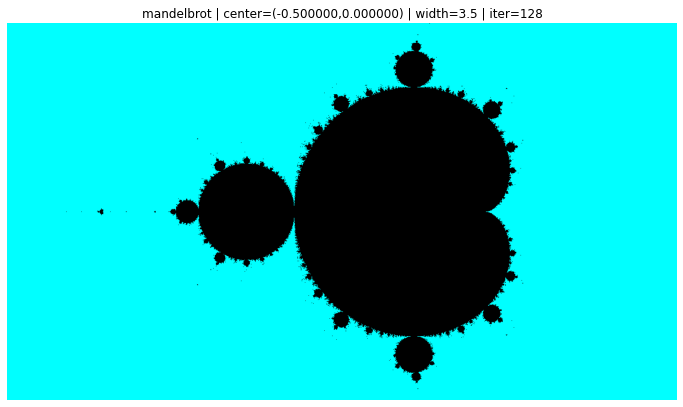

HDMI updated.


{'ok': True,
 'stats': {'min': 0,
  'max': 255,
  'mean': 132.05768229166668,
  'nonzero': 1431816},
 'fractal': 'mandelbrot',
 'mode': 0,
 'center': (-0.5, 0.0),
 'x_width': 3.5,
 'max_iter': 128,
 'julia_c': (-0.8, 0.156),
 'view': {'center_x': -0.5,
  'center_y': 0.0,
  'x_width': 3.5,
  'y_height': 1.96875,
  'x_min': -2.25,
  'x_max': 1.25,
  'y_min': -0.984375,
  'y_max': 0.984375,
  'x_jump': 0.002734375,
  'y_jump': 0.002734375},
 'vdma': {'mm2s_flags': ['HALTED', 'PARKED_OR_FRAME_SYNC'],
  's2mm_flags': ['DELAY_COUNT_IRQ', 'PARKED_OR_FRAME_SYNC']}}

In [ ]:
# basic manny
preset("mandelbrot_full", preview=True, force_display_restart=True)

Current state:
  fractal : tricorn
  center  : (0.0, 0.0)
  x_width : 3.5
  max_iter: 128
  julia_c : (-0.8, 0.156)
center = (0.000000000000, 0.000000000000)
x range = [-1.750000000000, 1.750000000000] width 3.5
y range = [-0.984375000000, 0.984375000000] height 1.96875
x_jump = 0.002734375, y_jump = 0.002734375

Rendering: tricorn
max_iter: 128 wait_s: 1.2
center = (0.000000000000, 0.000000000000)
x range = [-1.750000000000, 1.750000000000] width 3.5
y range = [-0.984375000000, 0.984375000000] height 1.96875
x_jump = 0.002734375, y_jump = 0.002734375
Captured frame stats: {'min': 0, 'max': 255, 'mean': 152.3578884548611, 'nonzero': 1651918}


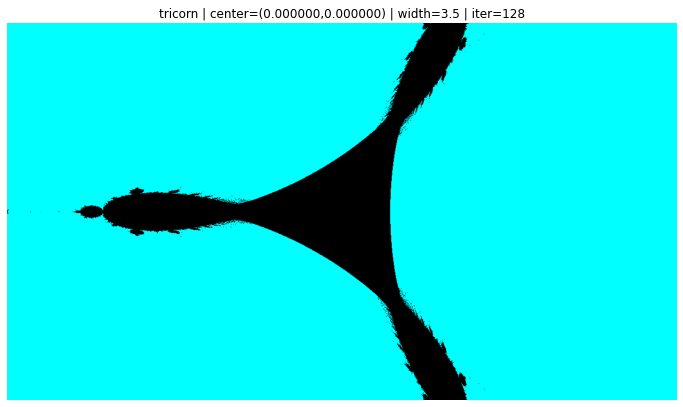

HDMI updated.


{'ok': True,
 'stats': {'min': 0,
  'max': 255,
  'mean': 152.3578884548611,
  'nonzero': 1651918},
 'fractal': 'tricorn',
 'mode': 3,
 'center': (0.0, 0.0),
 'x_width': 3.5,
 'max_iter': 128,
 'julia_c': (-0.8, 0.156),
 'view': {'center_x': 0.0,
  'center_y': 0.0,
  'x_width': 3.5,
  'y_height': 1.96875,
  'x_min': -1.75,
  'x_max': 1.75,
  'y_min': -0.984375,
  'y_max': 0.984375,
  'x_jump': 0.002734375,
  'y_jump': 0.002734375},
 'vdma': {'mm2s_flags': ['DELAY_COUNT_IRQ', 'PARKED_OR_FRAME_SYNC'],
  's2mm_flags': ['DELAY_COUNT_IRQ', 'PARKED_OR_FRAME_SYNC']}}

In [ ]:
# other ones, dont do more than 1 at a time
#preset("burning_ship_zoom", preview=True)
#preset("julia_airplane", preview=True)
preset("tricorn_full", preview=True)

In [ ]:
# commands
zoom_in(2, preview=False)
#pan_left(0.20, preview=False)
#set_iters(512, render=True, preview=False)
# mode_next(render=True, preview=True)

In [ ]:
# run cycle loop for demo
cycle_presets(wait_between=2.5)


Cycle 1 | Preset 1 / 7 : mandelbrot_full

Rendering: mandelbrot
max_iter: 128 wait_s: 1.2
center = (-0.500000000000, 0.000000000000)
x range = [-2.250000000000, 1.250000000000] width 3.5
y range = [-0.984375000000, 0.984375000000] height 1.96875
x_jump = 0.002734375, y_jump = 0.002734375
Captured frame stats: {'min': 0, 'max': 255, 'mean': 132.05768229166668, 'nonzero': 1431816}
HDMI updated.

Cycle 1 | Preset 2 / 7 : seahorse_valley

Rendering: mandelbrot
max_iter: 256 wait_s: 1.568
center = (-0.740000000000, 0.105000000000)
x range = [-0.750000000000, -0.730000000000] width 0.02
y range = [0.099375000000, 0.110625000000] height 0.01125
x_jump = 1.5625e-05, y_jump = 1.5625e-05
Captured frame stats: {'min': 0, 'max': 255, 'mean': 44.84248046875, 'nonzero': 486198}
HDMI updated.

Cycle 1 | Preset 3 / 7 : julia_dragon

Rendering: julia
max_iter: 256 wait_s: 1.568
Julia c: (-0.8, 0.156)
center = (0.000000000000, 0.000000000000)
x range = [-1.600000000000, 1.600000000000] width 3.2
y rang

HDMI updated.

Cycle 3 | Preset 5 / 7 : burning_ship_full

Rendering: burning_ship
max_iter: 128 wait_s: 1.2
center = (-0.500000000000, -0.500000000000)
x range = [-2.250000000000, 1.250000000000] width 3.5
y range = [-1.484375000000, 0.484375000000] height 1.96875
x_jump = 0.002734375, y_jump = 0.002734375
Captured frame stats: {'min': 0, 'max': 255, 'mean': 125.37426215277777, 'nonzero': 1359352}
HDMI updated.

Cycle 3 | Preset 6 / 7 : burning_ship_detail

Rendering: burning_ship
max_iter: 256 wait_s: 1.568
center = (-1.750000000000, -0.030000000000)
x range = [-1.810000000000, -1.690000000000] width 0.12
y range = [-0.063750000000, 0.003750000000] height 0.0675
x_jump = 9.375e-05, y_jump = 9.375e-05
Captured frame stats: {'min': 0, 'max': 255, 'mean': 152.55341796875, 'nonzero': 1654038}
HDMI updated.

Cycle 3 | Preset 7 / 7 : tricorn_full

Rendering: tricorn
max_iter: 128 wait_s: 1.2
center = (0.000000000000, 0.000000000000)
x range = [-1.750000000000, 1.750000000000] width 3.5
y r

HDMI updated.

Cycle 6 | Preset 2 / 7 : seahorse_valley

Rendering: mandelbrot
max_iter: 256 wait_s: 1.568
center = (-0.740000000000, 0.105000000000)
x range = [-0.750000000000, -0.730000000000] width 0.02
y range = [0.099375000000, 0.110625000000] height 0.01125
x_jump = 1.5625e-05, y_jump = 1.5625e-05
Captured frame stats: {'min': 0, 'max': 255, 'mean': 44.84248046875, 'nonzero': 486198}
HDMI updated.

Cycle 6 | Preset 3 / 7 : julia_dragon

Rendering: julia
max_iter: 256 wait_s: 1.568
Julia c: (-0.8, 0.156)
center = (0.000000000000, 0.000000000000)
x range = [-1.600000000000, 1.600000000000] width 3.2
y range = [-0.900000000000, 0.900000000000] height 1.8
x_jump = 0.0025, y_jump = 0.0025
Captured frame stats: {'min': 0, 'max': 255, 'mean': 161.17663845486112, 'nonzero': 1747534}
HDMI updated.

Cycle 6 | Preset 4 / 7 : julia_douady

Rendering: julia
max_iter: 256 wait_s: 1.568
Julia c: (-0.123, 0.745)
center = (0.000000000000, 0.000000000000)
x range = [-1.600000000000, 1.600000000000

HDMI updated.

Cycle 8 | Preset 6 / 7 : burning_ship_detail

Rendering: burning_ship
max_iter: 256 wait_s: 1.568
center = (-1.750000000000, -0.030000000000)
x range = [-1.810000000000, -1.690000000000] width 0.12
y range = [-0.063750000000, 0.003750000000] height 0.0675
x_jump = 9.375e-05, y_jump = 9.375e-05
Captured frame stats: {'min': 0, 'max': 255, 'mean': 152.55341796875, 'nonzero': 1654038}
HDMI updated.

Cycle 8 | Preset 7 / 7 : tricorn_full

Rendering: tricorn
max_iter: 128 wait_s: 1.2
center = (0.000000000000, 0.000000000000)
x range = [-1.750000000000, 1.750000000000] width 3.5
y range = [-0.984375000000, 0.984375000000] height 1.96875
x_jump = 0.002734375, y_jump = 0.002734375
Captured frame stats: {'min': 0, 'max': 255, 'mean': 152.3578884548611, 'nonzero': 1651918}
HDMI updated.

Cycle 9 | Preset 1 / 7 : mandelbrot_full

Rendering: mandelbrot
max_iter: 128 wait_s: 1.2
center = (-0.500000000000, 0.000000000000)
x range = [-2.250000000000, 1.250000000000] width 3.5
y range =

HDMI updated.

Cycle 11 | Preset 3 / 7 : julia_dragon

Rendering: julia
max_iter: 256 wait_s: 1.568
Julia c: (-0.8, 0.156)
center = (0.000000000000, 0.000000000000)
x range = [-1.600000000000, 1.600000000000] width 3.2
y range = [-0.900000000000, 0.900000000000] height 1.8
x_jump = 0.0025, y_jump = 0.0025
Captured frame stats: {'min': 0, 'max': 255, 'mean': 161.17663845486112, 'nonzero': 1747534}
HDMI updated.

Cycle 11 | Preset 4 / 7 : julia_douady

Rendering: julia
max_iter: 256 wait_s: 1.568
Julia c: (-0.123, 0.745)
center = (0.000000000000, 0.000000000000)
x range = [-1.600000000000, 1.600000000000] width 3.2
y range = [-0.900000000000, 0.900000000000] height 1.8
x_jump = 0.0025, y_jump = 0.0025
Captured frame stats: {'min': 0, 'max': 255, 'mean': 132.24195963541666, 'nonzero': 1433814}
HDMI updated.

Cycle 11 | Preset 5 / 7 : burning_ship_full

Rendering: burning_ship
max_iter: 128 wait_s: 1.2
center = (-0.500000000000, -0.500000000000)
x range = [-2.250000000000, 1.250000000000] 

...

Captured frame stats: {'min': 0, 'max': 255, 'mean': 132.24195963541666, 'nonzero': 1433814}
HDMI updated.

Cycle 57 | Preset 5 / 7 : burning_ship_full

Rendering: burning_ship
max_iter: 128 wait_s: 1.2
center = (-0.500000000000, -0.500000000000)
x range = [-2.250000000000, 1.250000000000] width 3.5
y range = [-1.484375000000, 0.484375000000] height 1.96875
x_jump = 0.002734375, y_jump = 0.002734375
Captured frame stats: {'min': 0, 'max': 255, 'mean': 125.37426215277777, 'nonzero': 1359352}
HDMI updated.

Cycle 57 | Preset 6 / 7 : burning_ship_detail

Rendering: burning_ship
max_iter: 256 wait_s: 1.568
center = (-1.750000000000, -0.030000000000)
x range = [-1.810000000000, -1.690000000000] width 0.12
y range = [-0.063750000000, 0.003750000000] height 0.0675
x_jump = 9.375e-05, y_jump = 9.375e-05
Captured frame stats: {'min': 0, 'max': 255, 'mean': 152.55341796875, 'nonzero': 1654038}
HDMI updated.

Cycle 57 | Preset 7 / 7 : tricorn_full

Rendering: tricorn
max_iter: 128 wait_s: 1.2
cen

Captured frame stats: {'min': 0, 'max': 255, 'mean': 132.05768229166668, 'nonzero': 1431816}
HDMI updated.

Cycle 60 | Preset 2 / 7 : seahorse_valley

Rendering: mandelbrot
max_iter: 256 wait_s: 1.568
center = (-0.740000000000, 0.105000000000)
x range = [-0.750000000000, -0.730000000000] width 0.02
y range = [0.099375000000, 0.110625000000] height 0.01125
x_jump = 1.5625e-05, y_jump = 1.5625e-05
Captured frame stats: {'min': 0, 'max': 255, 'mean': 44.84248046875, 'nonzero': 486198}
HDMI updated.

Cycle 60 | Preset 3 / 7 : julia_dragon

Rendering: julia
max_iter: 256 wait_s: 1.568
Julia c: (-0.8, 0.156)
center = (0.000000000000, 0.000000000000)
x range = [-1.600000000000, 1.600000000000] width 3.2
y range = [-0.900000000000, 0.900000000000] height 1.8
x_jump = 0.0025, y_jump = 0.0025
Captured frame stats: {'min': 0, 'max': 255, 'mean': 161.17663845486112, 'nonzero': 1747534}
HDMI updated.

Cycle 60 | Preset 4 / 7 : julia_douady

Rendering: julia
max_iter: 256 wait_s: 1.568
Julia c: (-0.

Captured frame stats: {'min': 0, 'max': 255, 'mean': 125.37426215277777, 'nonzero': 1359352}
HDMI updated.

Cycle 62 | Preset 6 / 7 : burning_ship_detail

Rendering: burning_ship
max_iter: 256 wait_s: 1.568
center = (-1.750000000000, -0.030000000000)
x range = [-1.810000000000, -1.690000000000] width 0.12
y range = [-0.063750000000, 0.003750000000] height 0.0675
x_jump = 9.375e-05, y_jump = 9.375e-05
Captured frame stats: {'min': 0, 'max': 255, 'mean': 152.55341796875, 'nonzero': 1654038}
HDMI updated.

Cycle 62 | Preset 7 / 7 : tricorn_full

Rendering: tricorn
max_iter: 128 wait_s: 1.2
center = (0.000000000000, 0.000000000000)
x range = [-1.750000000000, 1.750000000000] width 3.5
y range = [-0.984375000000, 0.984375000000] height 1.96875
x_jump = 0.002734375, y_jump = 0.002734375
Captured frame stats: {'min': 0, 'max': 255, 'mean': 152.3578884548611, 'nonzero': 1651918}
HDMI updated.

Cycle 63 | Preset 1 / 7 : mandelbrot_full

Rendering: mandelbrot
max_iter: 128 wait_s: 1.2
center = (

Captured frame stats: {'min': 0, 'max': 255, 'mean': 44.84248046875, 'nonzero': 486198}
HDMI updated.

Cycle 65 | Preset 3 / 7 : julia_dragon

Rendering: julia
max_iter: 256 wait_s: 1.568
Julia c: (-0.8, 0.156)
center = (0.000000000000, 0.000000000000)
x range = [-1.600000000000, 1.600000000000] width 3.2
y range = [-0.900000000000, 0.900000000000] height 1.8
x_jump = 0.0025, y_jump = 0.0025
Captured frame stats: {'min': 0, 'max': 255, 'mean': 161.17663845486112, 'nonzero': 1747534}
HDMI updated.

Cycle 65 | Preset 4 / 7 : julia_douady

Rendering: julia
max_iter: 256 wait_s: 1.568
Julia c: (-0.123, 0.745)
center = (0.000000000000, 0.000000000000)
x range = [-1.600000000000, 1.600000000000] width 3.2
y range = [-0.900000000000, 0.900000000000] height 1.8
x_jump = 0.0025, y_jump = 0.0025
Captured frame stats: {'min': 0, 'max': 255, 'mean': 132.24195963541666, 'nonzero': 1433814}
HDMI updated.

Cycle 65 | Preset 5 / 7 : burning_ship_full

Rendering: burning_ship
max_iter: 128 wait_s: 1.2


Captured frame stats: {'min': 0, 'max': 255, 'mean': 152.55341796875, 'nonzero': 1654038}
HDMI updated.

Cycle 67 | Preset 7 / 7 : tricorn_full

Rendering: tricorn
max_iter: 128 wait_s: 1.2
center = (0.000000000000, 0.000000000000)
x range = [-1.750000000000, 1.750000000000] width 3.5
y range = [-0.984375000000, 0.984375000000] height 1.96875
x_jump = 0.002734375, y_jump = 0.002734375
Captured frame stats: {'min': 0, 'max': 255, 'mean': 152.3578884548611, 'nonzero': 1651918}
HDMI updated.

Cycle 68 | Preset 1 / 7 : mandelbrot_full

Rendering: mandelbrot
max_iter: 128 wait_s: 1.2
center = (-0.500000000000, 0.000000000000)
x range = [-2.250000000000, 1.250000000000] width 3.5
y range = [-0.984375000000, 0.984375000000] height 1.96875
x_jump = 0.002734375, y_jump = 0.002734375
Captured frame stats: {'min': 0, 'max': 255, 'mean': 132.05768229166668, 'nonzero': 1431816}
HDMI updated.

Cycle 68 | Preset 2 / 7 : seahorse_valley

Rendering: mandelbrot
max_iter: 256 wait_s: 1.568
center = (-0.7